In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


# Wine segmentation

**Importing the libraries**

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
from sklearn.metrics import confusion_matrix
from sklearn import metrics

**Importing the dataset**

In [27]:
df = pd.read_csv(r'C:\Users\79308\Desktop\patel\Cluster\5 Wine\archive (5)\Wine.csv')
df.head(10)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,1
6,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290,1
7,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295,1
8,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045,1
9,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045,1


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


**EDA**

**Let’s create some simple plots to check out the data!**

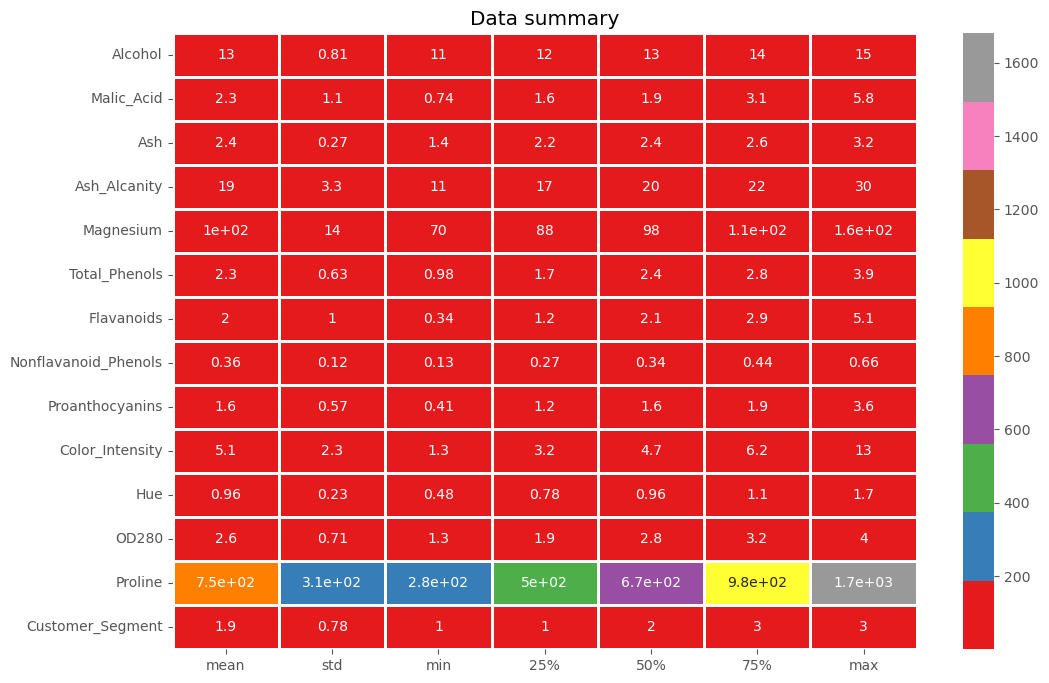

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(df.describe()[1:].transpose(),
            annot=True,linecolor="w",
            linewidth=2,cmap=sns.color_palette("Set1"))
plt.title("Data summary")
plt.show()

**Correlation Matrix**

<Axes: >

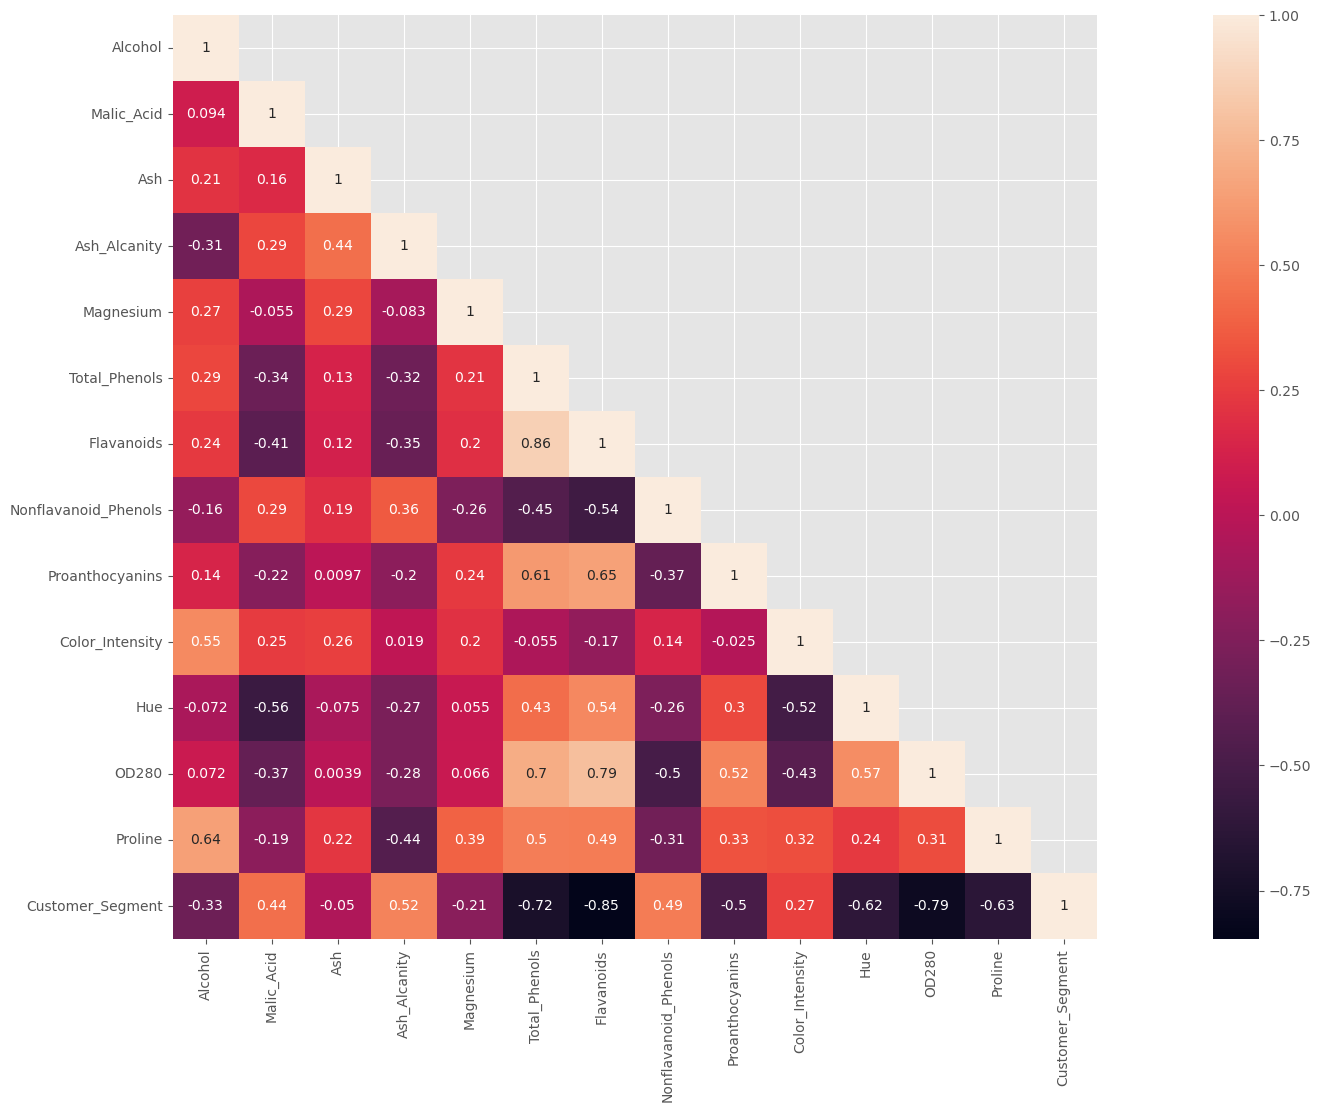

In [30]:
cor_mat= df[:].corr()
mask = np.array(cor_mat)
mask[np.tril_indices_from(mask)] = False
fig=plt.gcf()
fig.set_size_inches(30,12)
sns.heatmap(data=cor_mat,mask=mask,square=True,annot=True,cbar=True)

**Let's see the correlation for Customer Segment column in our dataset**

In [31]:
corr=df.corr()
corr.sort_values(by=["Customer_Segment"],ascending=False).iloc[0].sort_values(ascending=False)

Customer_Segment        1.000000
Ash_Alcanity            0.517859
Nonflavanoid_Phenols    0.489109
Malic_Acid              0.437776
Color_Intensity         0.265668
Ash                    -0.049643
Magnesium              -0.209179
Alcohol                -0.328222
Proanthocyanins        -0.499130
Hue                    -0.617369
Proline                -0.633717
Total_Phenols          -0.719163
OD280                  -0.788230
Flavanoids             -0.847498
Name: Customer_Segment, dtype: float64

**Let's see Percentage of customer group in the dataset!**

In [32]:
print('Goup 1:',len(df[df.Customer_Segment == 1]))
print('Group 2:',len(df[df.Customer_Segment == 2]))
print('Group 3:',len(df[df.Customer_Segment == 3]))

Goup 1: 59
Group 2: 71
Group 3: 48


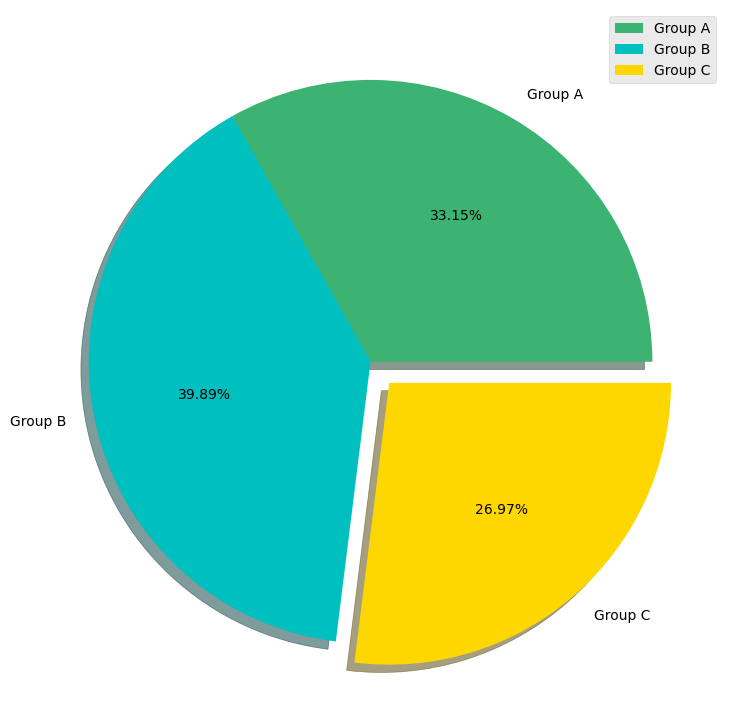

In [33]:
plt.rcParams['figure.figsize'] = (20, 10)
size = [59, 71, 48]
colors = ['mediumseagreen', 'c', 'gold']
labels = "Group A", "Group B", "Group C"
explode = [0, 0, 0.1]
plt.subplot(1, 2, 1)
plt.pie(size, colors = colors, labels = labels, explode = explode, shadow = True, autopct = '%.2f%%')
#plt.title('Different Visitors', fontsize = 20)
plt.axis('off')
plt.legend()

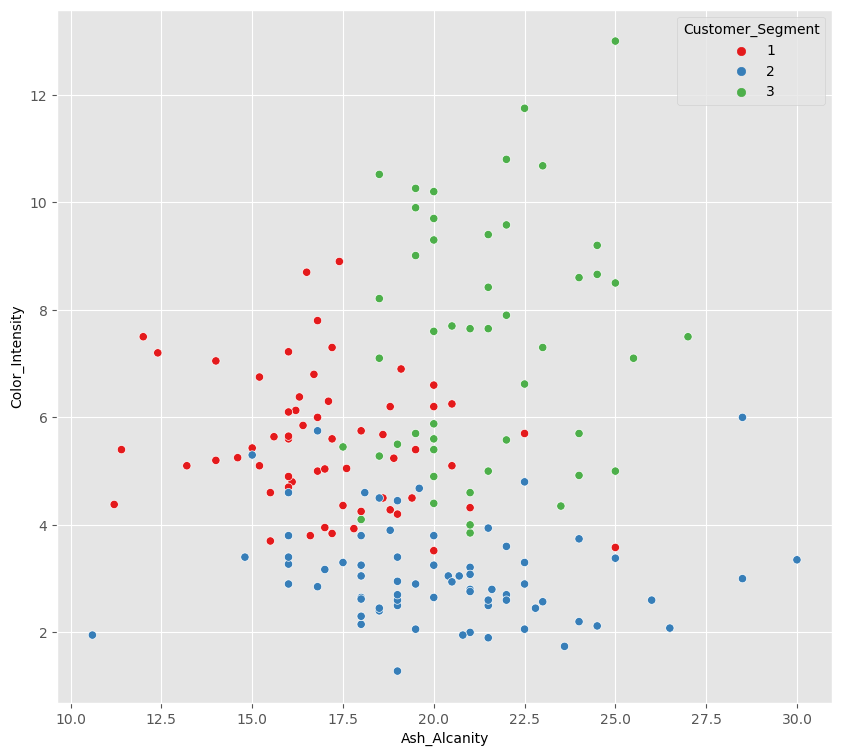

In [34]:
plt.figure(figsize=(10,9))
sns.scatterplot(x='Ash_Alcanity',y='Color_Intensity',data=df,palette='Set1', hue = 'Customer_Segment');

**Splitting the data into training set and test set**

In [35]:
X = df.drop('Customer_Segment',axis=1).values
y = df['Customer_Segment'].values

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 0)

**Feature Scalling**

In [37]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

**Applying PCA**

---
## Step 1: Baseline Model Comparison (LazyPredict)

Quick automated comparison of multiple models to establish baselines.


In [ ]:
from lazypredict.Supervised import LazyClassifier

lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = lazy_clf.fit(X_train, X_test, y_train, y_test)

print(models)


---
## Step 2: Final Pipeline (PyCaret)

Automated ML pipeline with PyCaret:
- `setup()` → preprocessing & configuration
- `compare_models()` → model selection
- `finalize_model()` → train on full data


In [ ]:
from pycaret.classification import *

clf_setup = setup(data=df, target='Customer_Segment', session_id=42, verbose=False)

# Compare models and select best
best_model = compare_models()

# Display comparison results
print(best_model)


In [ ]:
# Evaluate the best model
evaluate_model(best_model)


In [ ]:
# Finalize the model (train on full dataset)
final_model = finalize_model(best_model)

print('Final model:', final_model)